# Train TextCNN v3 (`data_ready_v1_3`)

Kim (2014) TextCNN topic classifier for hybrid RAG (Top-1/2/3 + macro-F1).

- Data: **`data/data_ready_v1_3`**
- Embedding: `python build_shared_embedding.py` → `shared_embedding_artifacts/`
- Default input: **`question_answer`** (`MAX_LEN=256`); baseline compare vs **question-only** (`MAX_LEN=128`)
- Artifacts: `pipeline_v1.3/textcnn_artifacts/` (local) or Kaggle working dir


In [140]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset


def load_artifacts(artifact_dir):
    artifact_dir = Path(artifact_dir)
    with open(artifact_dir / "tokenizer_vocab.json", "r", encoding="utf-8") as f:
        vocab = json.load(f)
    ckpt = torch.load(artifact_dir / "embedding.pt", map_location="cpu")
    stoi = vocab["stoi"]
    embedding_weight = ckpt["embedding_weight"]
    pad_idx = int(ckpt["pad_idx"])
    return stoi, embedding_weight, pad_idx


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True


Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [141]:
def detect_data_dir():
    candidates = [
        Path("data/data_ready_v1_3_k3"),
        Path("data/data_ready_v1_3"),
        Path("/content/data/data_ready_v1_3_k3"),
        Path("/content/data/data_ready_v1_3"),
        Path("../data/data_ready_v1_3_k3"),
        Path("../data/data_ready_v1_3"),
        Path("/kaggle/input/vnlegal-rag/data/data_ready_v1_3"),
        Path("/kaggle/working/vnlegal-rag/data/data_ready_v1_3"),
        Path("/kaggle/input/datasets/hngphtrn/legals/data_ready_v1_3"),
        Path("/kaggle/input/datasets/hngphtrn/legals-v1-3"),
        Path("/kaggle/input/datasets/hngphtrn/legals_v1_3"),
    ]
    for p in candidates:
        if p.exists() and (p / "qa_train.csv").exists():
            return p.resolve()
    raise FileNotFoundError(
        "Cannot find data_ready_v1_3 with qa_train.csv. "
        "Run: python pipeline_v1.3/prepare_data.py --out-dir data/data_ready_v1_3"
    )


DATA_DIR = detect_data_dir()
_pipeline = Path.cwd() / "pipeline_v1.3"
if not (_pipeline / "tokenizer_bootstrap.py").exists():
    _pipeline = Path.cwd()
ARTIFACT_DIR = Path(
    "/kaggle/working/textcnn_artifacts_v1_3"
    if Path("/kaggle").exists()
    else _pipeline / "textcnn_artifacts_v1_3"
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR =", DATA_DIR)
print("ARTIFACT_DIR =", ARTIFACT_DIR)

DATA_DIR = /content/data/data_ready_v1_3_k3
ARTIFACT_DIR = /kaggle/working/textcnn_artifacts_v1_3


In [142]:
qa_train = pd.read_csv(DATA_DIR / "qa_train.csv", sep="\t")
qa_val = pd.read_csv(DATA_DIR / "qa_val.csv", sep="\t")
qa_test = pd.read_csv(DATA_DIR / "qa_test.csv", sep="\t")

required_cols = {"question", "answer", "macro_domain"}
for name, df in [("train", qa_train), ("val", qa_val), ("test", qa_test)]:
    miss = required_cols - set(df.columns)
    if miss:
        raise ValueError(f"{name} missing columns: {miss}")

print("train:", qa_train.shape, "val:", qa_val.shape, "test:", qa_test.shape)
qa_train[["question", "macro_domain"]].head()


train: (23311, 14) val: (2841, 14) test: (2991, 14)


,question,macro_domain
0,"Theo Điều 5 Luật Địa chất và Khoáng sản, hội n...",other
1,"Theo Điều 5 của Luật, khi thực hiện hội nhập v...",other
2,Giả sử có một tranh chấp quốc tế phát sinh liê...,other
3,"Theo Điều 2 của Luật Địa chất và Khoáng sản, ""...",other
4,Hãy phân tích sự khác biệt và mối quan hệ giữa...,other


In [143]:
import sys
from pathlib import Path

# ── Canonical tokenizer (model/tokenizer.py) ───────────────────────────────
_pipeline_dir = None
for _p in [
    Path.cwd() / "pipeline_v1.3",
    Path.cwd(),
    Path.cwd().parent / "pipeline_v1.3",
    Path("/kaggle/working/vnlegal-rag") / "pipeline_v1.3",
]:
    _p = _p.resolve()
    if (_p / "tokenizer_bootstrap.py").is_file():
        _pipeline_dir = _p
        break
if _pipeline_dir is None:
    raise FileNotFoundError("Cannot locate pipeline_v1.3/tokenizer_bootstrap.py")
if str(_pipeline_dir) not in sys.path:
    sys.path.insert(0, str(_pipeline_dir))
from tokenizer_bootstrap import simple_tokenize, TOKENIZER_BACKEND


print(f"Tokenizer backend: {TOKENIZER_BACKEND}")


Tokenizer backend: simple_tokenize


In [144]:
PAD = "<PAD>"
UNK = "<UNK>"
pad_idx = None  # set after load_artifacts

# ── Training configuration ───────────────────────────────────────────────────
TEXT_MODE = "question_answer"  # "question" | "question_answer"
MAX_LEN = 256 if TEXT_MODE == "question_answer" else 128

FILTER_SIZES = [2, 3, 4, 5]
NUM_FILTERS = 128
DROPOUT = 0.5

LABEL_SMOOTHING = 0.05
USE_CLASS_WEIGHT = True

BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 15
PATIENCE = 4
MAX_NORM_FC = 3.0

_embed_candidates = [
    Path("/kaggle/input/datasets/hngphtrn/legal-embedding-v1-3"),
    Path("pipeline_v1.3/shared_embedding_artifacts_ab"),
    Path("pipeline_v1.3/shared_embedding_artifacts"),
    Path("../pipeline_v1.3/shared_embedding_artifacts_ab"),
    Path("../pipeline_v1.3/shared_embedding_artifacts"),
    Path.cwd() / "pipeline_v1.3" / "shared_embedding_artifacts_ab",
    Path.cwd() / "pipeline_v1.3" / "shared_embedding_artifacts",
]
SHARED_EMBED_DIR = None
for _p in _embed_candidates:
    if _p.exists() and (_p / "embedding.pt").exists():
        SHARED_EMBED_DIR = _p
        break
if SHARED_EMBED_DIR is None:
    raise FileNotFoundError(
        "No shared embedding dir with embedding.pt. Run: python build_shared_embedding.py"
    )

print("TEXT_MODE=", TEXT_MODE)
print("MAX_LEN=", MAX_LEN)
print("SHARED_EMBED_DIR=", SHARED_EMBED_DIR)

stoi, embedding_weight, _pad_ckpt = load_artifacts(SHARED_EMBED_DIR)
itos = {i: w for w, i in stoi.items()}
MAX_VOCAB = len(stoi)
pad_idx = stoi.get(PAD, stoi.get("PAD", 0))

_label_maps_path = DATA_DIR / "label_maps.json"
if _label_maps_path.exists():
    with open(_label_maps_path, "r", encoding="utf-8") as _f:
        _lm = json.load(_f)
    labels = list(_lm["label_list"])
    label2id = {str(k): int(v) for k, v in _lm["label2id"].items()}
    label2id = {k: label2id[k] for k in labels}
    id2label = {int(k): v for k, v in _lm["id2label"].items()}
else:
    labels = sorted(qa_train["macro_domain"].unique().tolist())
    label2id = {l: i for i, l in enumerate(labels)}
    id2label = {i: l for l, i in label2id.items()}

num_classes = len(labels)
print("Vocab size:", len(stoi), "| Num labels:", num_classes)

TEXT_MODE= question_answer
MAX_LEN= 256
SHARED_EMBED_DIR= pipeline_v1.3/shared_embedding_artifacts_ab
Vocab size: 6227 | Num labels: 6


In [145]:
def build_input_text(df, mode="question_answer"):
    if mode == "question":
        return df["question"].fillna("").astype(str)
    if mode == "question_answer":
        return (
            df["question"].fillna("").astype(str)
            + " "
            + df["answer"].fillna("").astype(str)
        )
    raise ValueError(f"Unsupported TEXT_MODE: {mode}")


def encode_text(text, max_len=MAX_LEN):
    from tokenizer_bootstrap import encode_text as _enc
    return _enc(text, stoi, max_len)


class QADomainDataset(Dataset):
    def __init__(self, texts, label_ids):
        self.texts = texts
        self.labels = label_ids

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return (
            torch.tensor(encode_text(self.texts[idx], MAX_LEN), dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )


train_texts = build_input_text(qa_train, TEXT_MODE).tolist()
val_texts = build_input_text(qa_val, TEXT_MODE).tolist()
test_texts = build_input_text(qa_test, TEXT_MODE).tolist()

train_labels = [label2id[x] for x in qa_train["macro_domain"].tolist()]
val_labels = [label2id[x] for x in qa_val["macro_domain"].tolist()]
test_labels = [label2id[x] for x in qa_test["macro_domain"].tolist()]

token_lens = [len(simple_tokenize(t)) for t in train_texts]
max_len_tokens = max(token_lens) if token_lens else 0
p95_len = float(np.percentile(token_lens, 95)) if token_lens else 0.0
p99_len = float(np.percentile(token_lens, 99)) if token_lens else 0.0
pct_truncated = 100.0 * sum(1 for L in token_lens if L > MAX_LEN) / max(len(token_lens), 1)

print(
    "max_len_tokens:", max_len_tokens,
    "| p95:", round(p95_len, 2),
    "| p99:", round(p99_len, 2),
)
print(f"pct samples truncated (len > MAX_LEN={MAX_LEN}): {pct_truncated:.2f}%")


max_len_tokens: 1240 | p95: 440.0 | p99: 562.0
pct samples truncated (len > MAX_LEN=256): 29.39%


In [146]:
import sys
from sklearn.utils.class_weight import compute_class_weight

_num_workers = 0 if sys.platform == "win32" else 2
_pin = torch.cuda.is_available()

train_ds = QADomainDataset(train_texts, train_labels)
val_ds = QADomainDataset(val_texts, val_labels)
test_ds = QADomainDataset(test_texts, test_labels)

class_counts = np.bincount(np.array(train_labels), minlength=num_classes)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=_num_workers, pin_memory=_pin
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_num_workers, pin_memory=_pin
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=_num_workers, pin_memory=_pin
)

print(len(train_ds), len(val_ds), len(test_ds))
print("Class counts:", class_counts.tolist())


23311 2841 2991
Class counts: [5580, 3903, 2409, 4515, 3889, 3015]


In [147]:
class TextCNNClassifier(nn.Module):
    def __init__(
        self,
        embedding_weight,
        num_classes,
        kernel_sizes,
        num_filters,
        dropout,
        pad_idx,
    ):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            embedding_weight,
            freeze=False,
            padding_idx=pad_idx,
        )
        embed_dim = embedding_weight.shape[1]
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    in_channels=embed_dim,
                    out_channels=num_filters,
                    kernel_size=k,
                )
                for k in kernel_sizes
            ]
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, token_ids):
        x = self.embedding(token_ids)
        x = x.transpose(1, 2)
        features = []
        for conv in self.convs:
            c = F.relu(conv(x))
            p = F.max_pool1d(c, kernel_size=c.size(2)).squeeze(2)
            features.append(p)
        cat = torch.cat(features, dim=1)
        cat = self.dropout(cat)
        return self.fc(cat)


In [148]:
# Backup existing checkpoint for baseline comparison (question-only)
BASELINE_CKPT = ARTIFACT_DIR / "textcnn_baseline_question_only.pt"
_best_existing = ARTIFACT_DIR / "textcnn_best.pt"
if _best_existing.is_file() and not BASELINE_CKPT.is_file():
    import shutil
    shutil.copy2(_best_existing, BASELINE_CKPT)
    print("Backed up baseline checkpoint:", BASELINE_CKPT)

model = TextCNNClassifier(
    embedding_weight=embedding_weight,
    num_classes=num_classes,
    kernel_sizes=FILTER_SIZES,
    num_filters=NUM_FILTERS,
    dropout=DROPOUT,
    pad_idx=pad_idx,
).to(device)

if USE_CLASS_WEIGHT:
    class_weights = torch.tensor(
        compute_class_weight(
            class_weight="balanced",
            classes=np.arange(num_classes),
            y=np.array(train_labels),
        ),
        dtype=torch.float32,
        device=device,
    )
else:
    class_weights = None

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = GradScaler("cuda", enabled=torch.cuda.is_available())

print("CrossEntropyLoss | label_smoothing=", LABEL_SMOOTHING)
if class_weights is not None:
    print("class_weights:", {lab: round(w.item(), 4) for lab, w in zip(labels, class_weights)})


CrossEntropyLoss | label_smoothing= 0.05
class_weights: {'Finance & Banking': 0.6963, 'Justice & Dispute Resolution': 0.9954, 'Labor & Insurance': 1.6128, 'State Organization & Admin': 0.8605, 'Transportation': 0.999, 'other': 1.2886}


In [149]:
def topk_accuracy(logits, labels, k=3):
    k = min(k, logits.size(1))
    topk = logits.topk(k, dim=1).indices
    correct = topk.eq(labels.view(-1, 1)).any(dim=1)
    return correct.float().mean().item()


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []
    logits_buf, labels_buf = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            pred = torch.argmax(logits, dim=1)
            y_true.extend(y.cpu().tolist())
            y_pred.extend(pred.cpu().tolist())
            logits_buf.append(logits.cpu())
            labels_buf.append(y.cpu())

    avg_loss = total_loss / len(loader.dataset)
    all_logits = torch.cat(logits_buf, dim=0)
    all_labels = torch.cat(labels_buf, dim=0)

    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return {
        "loss": avg_loss,
        "acc_top1": topk_accuracy(all_logits, all_labels, k=1),
        "acc_top2": topk_accuracy(all_logits, all_labels, k=2),
        "acc_top3": topk_accuracy(all_logits, all_labels, k=3),
        "macro_f1": macro_f1,
        "y_true": y_true,
        "y_pred": y_pred,
    }


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        with torch.no_grad():
            w = model.fc.weight
            norm = w.norm(2)
            if norm > MAX_NORM_FC:
                w.mul_(MAX_NORM_FC / (norm + 1e-6))
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


In [150]:
best_path = ARTIFACT_DIR / "textcnn_best.pt"
best_macro_f1 = -1.0
patience_counter = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_metrics = evaluate(model, val_loader)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_acc_top1": val_metrics["acc_top1"],
        "val_acc_top2": val_metrics["acc_top2"],
        "val_acc_top3": val_metrics["acc_top3"],
        "val_macro_f1": val_metrics["macro_f1"],
    })

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc_top1={val_metrics['acc_top1']:.4f} | "
        f"val_acc_top2={val_metrics['acc_top2']:.4f} | "
        f"val_acc_top3={val_metrics['acc_top3']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f}\n"
    )

    current_score = val_metrics["macro_f1"]
    if current_score > best_macro_f1:
        best_macro_f1 = current_score
        patience_counter = 0
        torch.save(model.state_dict(), best_path)
        print(f"  -> saved best checkpoint (val_macro_f1={best_macro_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

print(f"Best val_macro_f1={best_macro_f1:.4f} | checkpoint={best_path}")


Epoch 01/15 | train_loss=0.4995 | val_loss=0.7178 | val_acc_top1=0.7779 | val_acc_top2=0.9011 | val_acc_top3=0.9391 | val_macro_f1=0.7527

  -> saved best checkpoint (val_macro_f1=0.7527)
Epoch 02/15 | train_loss=0.3224 | val_loss=0.7263 | val_acc_top1=0.7758 | val_acc_top2=0.8909 | val_acc_top3=0.9250 | val_macro_f1=0.7539

  -> saved best checkpoint (val_macro_f1=0.7539)
Epoch 03/15 | train_loss=0.3141 | val_loss=0.7641 | val_acc_top1=0.7768 | val_acc_top2=0.8874 | val_acc_top3=0.9271 | val_macro_f1=0.7549

  -> saved best checkpoint (val_macro_f1=0.7549)
Epoch 04/15 | train_loss=0.3089 | val_loss=0.7715 | val_acc_top1=0.7652 | val_acc_top2=0.8772 | val_acc_top3=0.9296 | val_macro_f1=0.7341

Epoch 05/15 | train_loss=0.3065 | val_loss=0.7585 | val_acc_top1=0.7716 | val_acc_top2=0.8895 | val_acc_top3=0.9229 | val_macro_f1=0.7441

Epoch 06/15 | train_loss=0.3056 | val_loss=0.7865 | val_acc_top1=0.7709 | val_acc_top2=0.8641 | val_acc_top3=0.9109 | val_macro_f1=0.7474

Epoch 07/15 | train

In [151]:
model.load_state_dict(torch.load(best_path, map_location=device))
test_metrics = evaluate(model, test_loader)

print("Test Loss:", round(test_metrics["loss"], 4))
print("Test Top-1 Accuracy:", round(test_metrics["acc_top1"], 4))
print("Test Top-2 Accuracy:", round(test_metrics["acc_top2"], 4))
print("Test Top-3 Accuracy:", round(test_metrics["acc_top3"], 4))
print("Test Macro-F1:", round(test_metrics["macro_f1"], 4))

y_true, y_pred = test_metrics["y_true"], test_metrics["y_pred"]
report = classification_report(y_true, y_pred, target_names=labels, zero_division=0)
print(report)

report_path = ARTIFACT_DIR / "classification_report.txt"
report_path.write_text(report, encoding="utf-8")
print("Saved:", report_path)


Test Loss: 0.6468
Test Top-1 Accuracy: 0.8445
Test Top-2 Accuracy: 0.9214
Test Top-3 Accuracy: 0.9652
Test Macro-F1: 0.7932
                              precision    recall  f1-score   support

           Finance & Banking       0.97      0.89      0.93       741
Justice & Dispute Resolution       0.91      0.99      0.95       729
           Labor & Insurance       0.55      0.61      0.58        18
  State Organization & Admin       0.66      0.96      0.78       609
              Transportation       0.91      1.00      0.96       300
                       other       0.88      0.42      0.57       594

                    accuracy                           0.84      2991
                   macro avg       0.81      0.81      0.79      2991
                weighted avg       0.87      0.84      0.83      2991

Saved: /kaggle/working/textcnn_artifacts_v1_3/classification_report.txt


## Phase 1: Present-label Macro-F1

Recompute Macro-F1 only on classes with `support > 0` in test set.
`Labor & Insurance` has zero test samples — sklearn computes correctly over all configured labels, but the metric doesn't reflect performance on classes actually present.

In [152]:
present_labels = sorted(set(y_true))
all_labels = list(range(num_classes))

macro_f1_all = f1_score(y_true, y_pred, average="macro", labels=all_labels, zero_division=0)
macro_f1_present = f1_score(y_true, y_pred, average="macro", labels=present_labels, zero_division=0)

print(f"Macro-F1 (all configured labels, {len(all_labels)} classes) = {macro_f1_all:.4f}")
print(f"Macro-F1 (present test labels,   {len(present_labels)} classes) = {macro_f1_present:.4f}")
print()

missing_labels = set(all_labels) - set(present_labels)
if missing_labels:
    missing_names = [id2label[i] for i in sorted(missing_labels)]
    print(f"Classes with support=0 in test: {missing_names}")

print("\nClassification report (present labels only):")
present_names = [id2label[i] for i in present_labels]
print(classification_report(y_true, y_pred, labels=present_labels, target_names=present_names, zero_division=0))

Macro-F1 (all configured labels, 6 classes) = 0.7932
Macro-F1 (present test labels,   6 classes) = 0.7932


Classification report (present labels only):
                              precision    recall  f1-score   support

           Finance & Banking       0.97      0.89      0.93       741
Justice & Dispute Resolution       0.91      0.99      0.95       729
           Labor & Insurance       0.55      0.61      0.58        18
  State Organization & Admin       0.66      0.96      0.78       609
              Transportation       0.91      1.00      0.96       300
                       other       0.88      0.42      0.57       594

                    accuracy                           0.84      2991
                   macro avg       0.81      0.81      0.79      2991
                weighted avg       0.87      0.84      0.83      2991



## Phase 2: Confusion Matrix Analysis

Focus on `other` class (recall=0.24) — which classes absorb its misclassifications?
`other` = merge of Security & Defense + Civil & Investment + Industry, Resources & Environment.

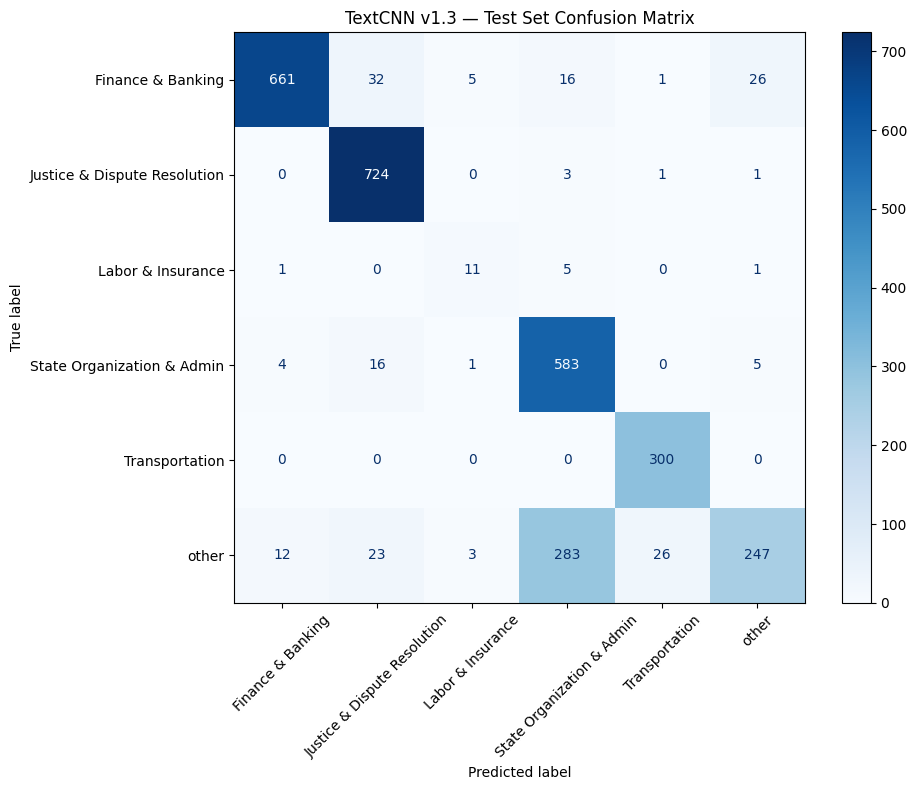

Saved: /kaggle/working/textcnn_artifacts_v1_3/confusion_matrix.png


In [153]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
ax.set_title("TextCNN v1.3 — Test Set Confusion Matrix")
plt.tight_layout()
plt.savefig(str(ARTIFACT_DIR / "confusion_matrix.png"), dpi=150)
plt.show()
print("Saved:", ARTIFACT_DIR / "confusion_matrix.png")

In [154]:
other_idx = label2id["other"]

print("=== 'other' row analysis (true=other, predicted=?) ===")
other_row = cm[other_idx]
other_total = other_row.sum()
for i, count in enumerate(other_row):
    if count > 0:
        pct = 100.0 * count / max(other_total, 1)
        marker = " <-- correct" if i == other_idx else ""
        print(f"  other → {labels[i]}: {count} ({pct:.1f}%){marker}")

print(f"\n  Total 'other' samples: {other_total}")
print(f"  Correctly classified:  {other_row[other_idx]} ({100*other_row[other_idx]/max(other_total,1):.1f}%)")
print(f"  Misclassified:         {other_total - other_row[other_idx]} ({100*(other_total - other_row[other_idx])/max(other_total,1):.1f}%)")

print("\n=== Reverse: which classes are wrongly predicted AS 'other' ===")
other_col = cm[:, other_idx]
for i, count in enumerate(other_col):
    if count > 0 and i != other_idx:
        row_total = cm[i].sum()
        pct = 100.0 * count / max(row_total, 1)
        print(f"  {labels[i]} → other: {count} ({pct:.1f}% of {labels[i]} samples)")

=== 'other' row analysis (true=other, predicted=?) ===
  other → Finance & Banking: 12 (2.0%)
  other → Justice & Dispute Resolution: 23 (3.9%)
  other → Labor & Insurance: 3 (0.5%)
  other → State Organization & Admin: 283 (47.6%)
  other → Transportation: 26 (4.4%)
  other → other: 247 (41.6%) <-- correct

  Total 'other' samples: 594
  Correctly classified:  247 (41.6%)
  Misclassified:         347 (58.4%)

=== Reverse: which classes are wrongly predicted AS 'other' ===
  Finance & Banking → other: 26 (3.5% of Finance & Banking samples)
  Justice & Dispute Resolution → other: 1 (0.1% of Justice & Dispute Resolution samples)
  Labor & Insurance → other: 1 (5.6% of Labor & Insurance samples)
  State Organization & Admin → other: 5 (0.8% of State Organization & Admin samples)


In [155]:
def predict_topk_textcnn(model, text, stoi, labels, max_len, k=3, device="cpu"):
    from tokenizer_bootstrap import encode_text as encode_text_ids

    model.eval()
    ids = encode_text_ids(text, stoi, max_len)
    x = torch.tensor([ids], dtype=torch.long, device=device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0)
    top_vals, top_idx = torch.topk(probs, k=min(k, len(labels)))
    return [
        {"label": labels[int(idx)], "probability": float(prob)}
        for prob, idx in zip(top_vals.cpu(), top_idx.cpu())
    ]


sample_query = "Người lao động được hưởng bảo hiểm xã hội trong trường hợp nào?"
print(
    predict_topk_textcnn(
        model=model,
        text=sample_query,
        stoi=stoi,
        labels=labels,
        max_len=MAX_LEN,
        k=3,
        device=device,
    )
)


[{'label': 'Labor & Insurance', 'probability': 0.9913063645362854}, {'label': 'other', 'probability': 0.0029029925353825092}, {'label': 'Transportation', 'probability': 0.0024266308173537254}]


In [156]:
def make_loader(texts, label_ids, max_len):
    def _enc(text):
        from tokenizer_bootstrap import encode_text as _enc_fn
        return _enc_fn(text, stoi, max_len)

    class _DS(Dataset):
        def __init__(self):
            self.texts = texts
            self.labels = label_ids

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            return (
                torch.tensor(_enc(self.texts[idx]), dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long),
            )

    return DataLoader(
        _DS(), batch_size=BATCH_SIZE, shuffle=False, num_workers=_num_workers, pin_memory=_pin
    )


def eval_variant(model, qa_df, text_mode, max_len):
    global criterion
    texts = build_input_text(qa_df, text_mode).tolist()
    lbls = [label2id[x] for x in qa_df["macro_domain"].tolist()]
    loader = make_loader(texts, lbls, max_len)
    return evaluate(model, loader)


# Question-only evaluation of the NEW model (realistic inference scenario)
print("=== Question-only eval of NEW model (question text, MAX_LEN=128) ===")
_m_q = eval_variant(model, qa_test, "question", 128)
print(f"  Top-1={_m_q['acc_top1']:.4f} | Top-2={_m_q['acc_top2']:.4f} | Top-3={_m_q['acc_top3']:.4f} | Macro-F1={_m_q['macro_f1']:.4f}")

new_metrics = {
    "acc_top1": test_metrics["acc_top1"],
    "acc_top2": test_metrics["acc_top2"],
    "acc_top3": test_metrics["acc_top3"],
    "macro_f1": test_metrics["macro_f1"],
    "loss": test_metrics["loss"],
}

new_q_metrics = {
    "acc_top1": _m_q["acc_top1"],
    "acc_top2": _m_q["acc_top2"],
    "acc_top3": _m_q["acc_top3"],
    "macro_f1": _m_q["macro_f1"],
    "loss": _m_q["loss"],
}

old_metrics = None
if BASELINE_CKPT.is_file():
    baseline_state = torch.load(BASELINE_CKPT, map_location=device)
    baseline_vocab_size = baseline_state["embedding.weight"].shape[0]
    if baseline_vocab_size == embedding_weight.shape[0]:
        baseline_model = TextCNNClassifier(
            embedding_weight=embedding_weight,
            num_classes=num_classes,
            kernel_sizes=FILTER_SIZES,
            num_filters=NUM_FILTERS,
            dropout=DROPOUT,
            pad_idx=pad_idx,
        ).to(device)
        baseline_model.load_state_dict(baseline_state)
        _m = eval_variant(baseline_model, qa_test, "question", 128)
        old_metrics = {
            "acc_top1": _m["acc_top1"],
            "acc_top2": _m["acc_top2"],
            "acc_top3": _m["acc_top3"],
            "macro_f1": _m["macro_f1"],
            "loss": _m["loss"],
        }
        print(f"\nBaseline (question-only) evaluated from {BASELINE_CKPT}")
    else:
        print(f"\n[skip] Baseline vocab={baseline_vocab_size} != current vocab={embedding_weight.shape[0]}; cannot compare old checkpoint.")
else:
    print("[warn] No baseline checkpoint; skip question-only comparison.")

def _row(name, m):
    if m is None:
        return f"| {name} | — | — | — | — |"
    return f"| {name} | {m['acc_top1']:.4f} | {m['acc_top2']:.4f} | {m['acc_top3']:.4f} | {m['macro_f1']:.4f} |"

print("\n| Variant | Top-1 | Top-2 | Top-3 | Macro-F1 |")
print("|---------|-------|-------|-------|----------|")
if old_metrics:
    print(_row("Old baseline (question)", old_metrics))
print(_row("New (question_answer)", new_metrics))
print(_row("New (question-only)", new_q_metrics))
delta_q = {k: new_q_metrics[k] - new_metrics[k] for k in ("acc_top1", "acc_top2", "acc_top3", "macro_f1")}
print(
    f"| Δ q_only vs q+a | {delta_q['acc_top1']:+.4f} | "
    f"{delta_q['acc_top2']:+.4f} | "
    f"{delta_q['acc_top3']:+.4f} | "
    f"{delta_q['macro_f1']:+.4f} |"
)

comparison = {
    "test_split": "qa_test",
    "new_question_answer": {"text_mode": TEXT_MODE, "max_len": MAX_LEN, **new_metrics},
    "new_question_only": {"text_mode": "question", "max_len": 128, **new_q_metrics},
}
if old_metrics:
    comparison["old_baseline_question_only"] = {"text_mode": "question", "max_len": 128, **old_metrics}

with open(ARTIFACT_DIR / "baseline_comparison.json", "w", encoding="utf-8") as f:
    json.dump(comparison, f, ensure_ascii=False, indent=2)
print("Saved:", ARTIFACT_DIR / "baseline_comparison.json")

=== Question-only eval of NEW model (question text, MAX_LEN=128) ===
  Top-1=0.7981 | Top-2=0.8850 | Top-3=0.9468 | Macro-F1=0.7573

[skip] Baseline vocab=6087 != current vocab=6227; cannot compare old checkpoint.

| Variant | Top-1 | Top-2 | Top-3 | Macro-F1 |
|---------|-------|-------|-------|----------|
| New (question_answer) | 0.8445 | 0.9214 | 0.9652 | 0.7932 |
| New (question-only) | 0.7981 | 0.8850 | 0.9468 | 0.7573 |
| Δ q_only vs q+a | -0.0465 | -0.0364 | -0.0184 | -0.0359 |
Saved: /kaggle/working/textcnn_artifacts_v1_3/baseline_comparison.json


In [157]:
metadata_out = {
    "model_name": "TextCNN",
    "reference": "Kim 2014",
    "version": "textcnn_v1_3",
    "tokenizer_backend": TOKENIZER_BACKEND,
    "text_mode": TEXT_MODE,
    "shared_embed_dir": str(SHARED_EMBED_DIR),
    "data_dir": str(DATA_DIR),
    "max_len": MAX_LEN,
    "max_vocab_cap": MAX_VOCAB,
    "filter_sizes": list(FILTER_SIZES),
    "num_filters": NUM_FILTERS,
    "dropout": DROPOUT,
    "label_smoothing": LABEL_SMOOTHING,
    "use_class_weight": USE_CLASS_WEIGHT,
    "labels": labels,
    "num_classes": num_classes,
    "best_metric": "val_macro_f1",
    "label2id": label2id,
    "id2label": {str(k): v for k, v in id2label.items()},
    "pad_token": PAD,
    "unk_token": UNK,
    "best_val_macro_f1": round(float(best_macro_f1), 6),
    "train_strategy": {
        "optimizer": "adam",
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout": DROPOUT,
        "use_class_weight": USE_CLASS_WEIGHT,
        "early_stop_metric": "val_macro_f1",
        "early_stop_patience": PATIENCE,
        "max_norm_fc": MAX_NORM_FC,
    },
}

with open(ARTIFACT_DIR / "tokenizer_vocab.json", "w", encoding="utf-8") as f:
    json.dump({"stoi": stoi, "itos": {str(k): v for k, v in itos.items()}}, f, ensure_ascii=False)

with open(ARTIFACT_DIR / "textcnn_meta.json", "w", encoding="utf-8") as f:
    json.dump(metadata_out, f, ensure_ascii=False, indent=2)

with open(ARTIFACT_DIR / "training_history.json", "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

pd.DataFrame(history).to_csv(ARTIFACT_DIR / "train_history.csv", index=False)
print("Saved artifacts at:", ARTIFACT_DIR)


Saved artifacts at: /kaggle/working/textcnn_artifacts_v1_3
